### **Objetivo**

Estudar comunidades misóginas dentro do Reddit, analisando o discurso e a estrutura de relacionamento entre comunidades.

---

### **Ferramentas**

As ferramentas amplamente utilizadas na literatura para coleta de dados do Reddit se demonstraram de difícil acesso atualmente: a API oficial (PRAW) exige aprovação manual com tempo de resposta indefinido, e o PushShift — repositório histórico de posts — apresenta instabilidade estrutural desde 2023.

Diante disso, optou-se por realizar web scraping diretamente nas páginas HTML do Reddit. Foram utilizadas duas bibliotecas Python:

- **requests** — realiza as requisições HTTP para cada URL coletada
- **BeautifulSoup** — interpreta o HTML retornado e extrai os dados estruturados (título, autor, score, timestamp, etc.)

Para garantir a estabilidade da coleta, foi utilizado o **old.reddit.com** — versão legada da plataforma renderizada inteiramente em HTML estático, sem dependência de JavaScript. Isso elimina a necessidade de um navegador real (Selenium/Playwright) e torna o parsing mais previsível e robusto.

---

## **Metodologia de Coleta**

### Amostragem Snowball

A coleta foi estruturada como um processo de amostragem snowball em dois níveis, inspirado em Farrell et al. (2019) e Ribeiro et al. (2020):

**1. Definição da seed**

Um conjunto inicial de subreddits foi selecionado manualmente com base na literatura sobre o manosphere, cobrindo diferentes correntes ideológicas: Red Pill, MGTOW, Incel, MRA (Men's Rights Activists) e PUA (Pick-up Artists), além de comunidades de monitoramento e saída do movimento (ex: r/exredpill, r/IncelTears).

**2. Expansão recursiva**

A partir dos subreddits da seed, o algoritmo opera em ciclos de profundidade crescente:
```
Subreddits (seed)
      ↓
Coleta de posts
      ↓
Extração de autores
      ↓
Coleta do histórico de posts de cada autor
      ↓
Extração de novos subreddits frequentados
      ↓
Nova rodada de coleta (profundidade + 1)
```

Cada ciclo expande a rede a partir dos usuários — a premissa é que membros do manosphere transitam entre múltiplas comunidades relacionadas, e essa sobreposição de usuários é o principal mecanismo de descoberta de novas comunidades relevantes.

**3. Critérios de parada**

O processo é interrompido quando uma das condições é atingida:
- Profundidade máxima definida (MAX_SNOWBALL_DEPTH)
- Nenhum subreddit novo é descoberto (saturação)

---

## **Resultados**

In [12]:
import pandas as pd
import json
import os
import matplotlib.pyplot as plt
import re
import numpy as np


In [2]:
import os
import json
import pandas as pd

rows = []
erros = []

# Itera por cada profundidade
for depth in range(3 + 1):
    dir_ = f"data3/{depth}/subreddits"
    if not os.path.exists(dir_):
        continue
    for filename in os.listdir(dir_):
        if filename.endswith(".json"):
            path = os.path.join(dir_, filename)
            try:
                with open(path, "r", encoding="utf-8") as f:
                    posts = json.load(f)
                # Adiciona a profundidade em cada post para rastreabilidade
                for post in posts:
                    post["depth"] = depth
                rows.extend(posts)
            except json.JSONDecodeError:
                erros.append(path)

print(f"Arquivos com erro: {len(erros)}")
print(f"Posts carregados: {len(rows)}")

df = pd.DataFrame(rows)
df.head()

Arquivos com erro: 0
Posts carregados: 843859


,id,title,author,subreddit,timestamp,score,comments_text,url,depth
0,t3_2nj2ed,My compilation of posts on why TRP is sexist a...,IAmAN00bie,thebluepill,2014-11-27T00:04:59+00:00,866,224 comments,/r/TheBluePill/comments/2nj2ed/my_compilation_...,0
1,t3_1rw6rcv,"Looking for anonymous interviewees in Quebec, ...",Huge-Guidance-6068,thebluepill,2026-03-17T13:37:32+00:00,1,1 comment,/r/TheBluePill/comments/1rw6rcv/looking_for_an...,0
2,t3_1rf56ft,forensic psychology research,SecurityGreedy4928,thebluepill,2026-02-26T08:52:58+00:00,3,1 comment,/r/TheBluePill/comments/1rf56ft/forensic_psych...,0
3,t3_1r3w6h7,AP Research Survey,g1itt3r_plum,thebluepill,2026-02-13T17:58:32+00:00,6,comment,/r/TheBluePill/comments/1r3w6h7/ap_research_su...,0
4,t3_1r397fn,[Satire] A 4-Part Comprehensive Guide to The R...,Polla_Tronante,thebluepill,2026-02-12T23:33:44+00:00,3,comment,/r/TheBluePill/comments/1r397fn/satire_a_4part...,0


In [3]:
print(f"Quantidade de subreddits únicos: {df['subreddit'].nunique()}")
print(f"Quantidade de autores únicos: {df['author'].nunique()}")
print(f"Quantidade de posts carregados: {len(df)}")

Quantidade de subreddits únicos: 4454
Quantidade de autores únicos: 494132
Quantidade de posts carregados: 843859


---

#### 1. Análise dos subreddits

In [15]:
x = df.groupby("subreddit").size().sort_values(ascending=False)
x.describe()

count    4454.000000
mean      189.460934
std        40.585958
min         1.000000
25%       200.000000
50%       200.000000
75%       200.000000
max       224.000000
dtype: float64

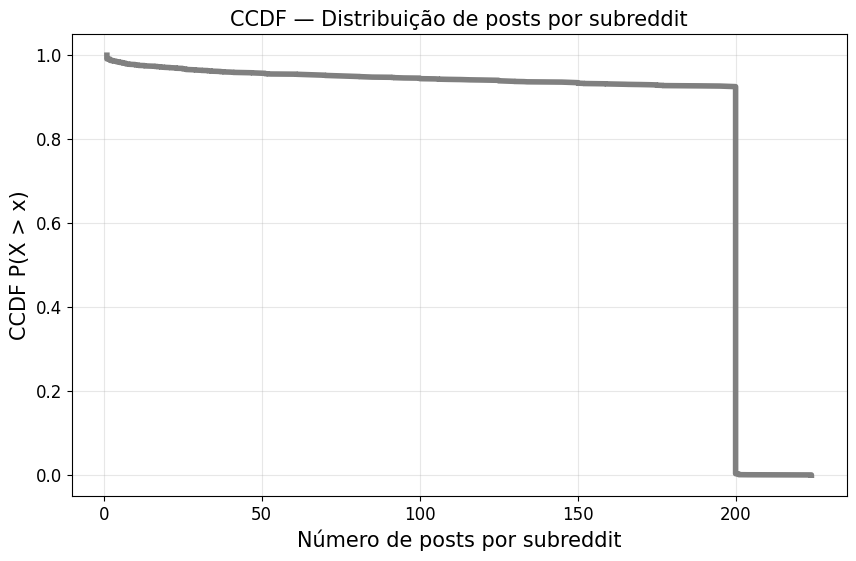

In [38]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Agrupamento e ordenação (permanecem iguais)
x = df.groupby("subreddit").size()
sorted_values = np.sort(x.values)

# 2. Cálculo da CCDF: P(X > x) é 1 - CDF
# Calculamos a proporção acumulada e subtraímos de 1
cdf = np.arange(1, len(sorted_values) + 1) / len(sorted_values)
ccdf = 1 - cdf

plt.figure(figsize=(10, 6))

# 3. Plotagem da CCDF
plt.plot(sorted_values, ccdf, linewidth=4, color='gray')

plt.xlabel("Número de posts por subreddit", fontsize=15)
plt.ylabel("CCDF P(X > x)", fontsize=15)
plt.title("CCDF — Distribuição de posts por subreddit", fontsize=15)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

A grande maioria dos posts bateram no teto de 200 posts limitado no código, ou seja, foram alcançados subreddits ativos, com muitas postagens

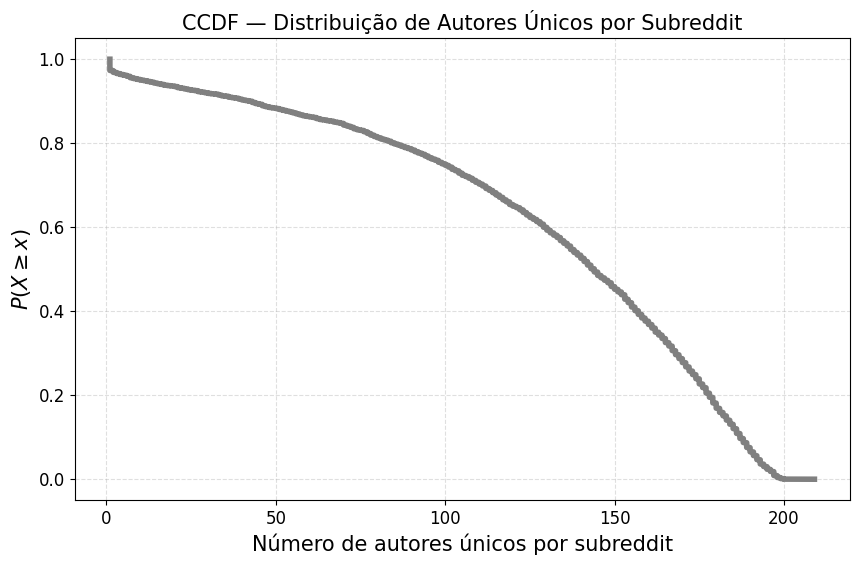

In [45]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Calculando o número de autores únicos por subreddit
# nunique() garante que cada usuário seja contado apenas uma vez por subreddit
autores_por_sub = df.groupby("subreddit")["author"].nunique()

# 2. Preparando os dados para a CCDF
sorted_values = np.sort(autores_por_sub.values)
n = len(sorted_values)
# P(X >= x)
ccdf = 1 - np.arange(1, n + 1) / n


plt.figure(figsize=(10, 6))
plt.plot(sorted_values, ccdf, linewidth=4, color='gray')
plt.xlabel("Número de autores únicos por subreddit", fontsize=15)
plt.ylabel(r"$P(X \geq x)$", fontsize=15)
plt.title("CCDF — Distribuição de Autores Únicos por Subreddit", fontsize=15)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

plt.grid(True, which="both", linestyle="--", alpha=0.4)
plt.show()

Quando olhamos o números de usuários que plubicaram posts por subreddits, é possível ver uma distribuição maior, ou seja, é comum que tenham usuários mais ativos que publicam mais

---

#### 2. Análise dos usuários

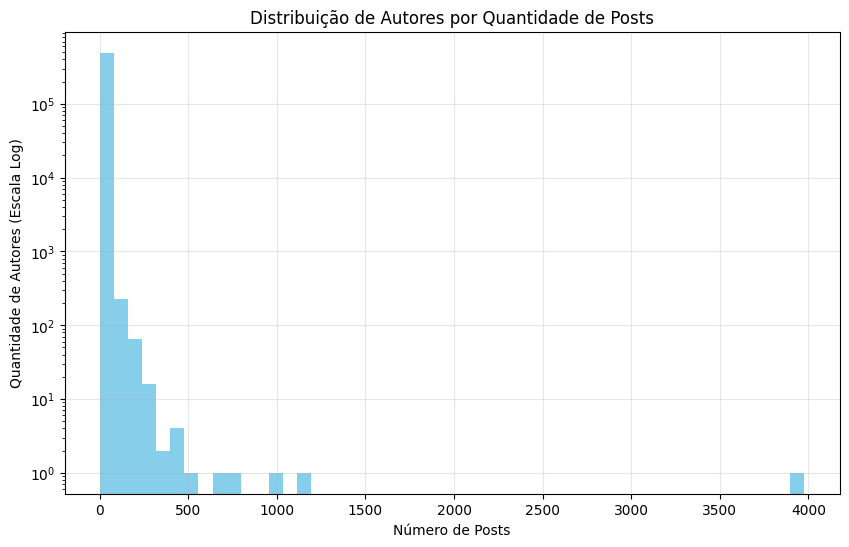

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

distintos_por_autor = df.groupby('author').size()

plt.figure(figsize=(10, 6))
plt.hist(distintos_por_autor, bins=50, color='skyblue')
plt.yscale('log')
plt.xlabel("Número de Posts")
plt.ylabel("Quantidade de Autores (Escala Log)")
plt.title("Distribuição de Autores por Quantidade de Posts")
plt.grid(True, alpha=0.3)
plt.show()

In [68]:
distintos_por_autor.describe()

count    494132.000000
mean          1.688541
std           7.773709
min           1.000000
25%           1.000000
50%           1.000000
75%           1.000000
max        3977.000000
dtype: float64

A grande maioria nos autores fizeram apenas uma publicação, portanto, por mais que existam bastnates usuários mais ativos dentro dos subreddits, isso é feito por uma pequena comunidade de autores

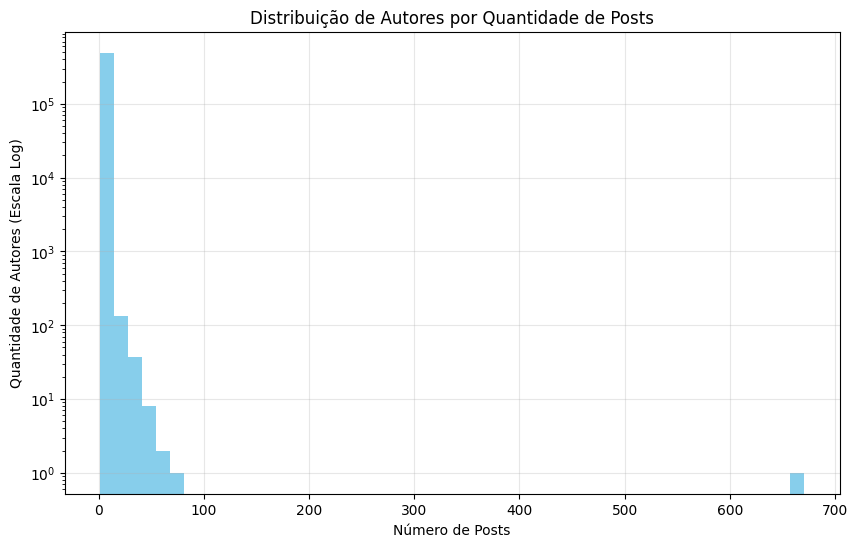

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns

distintos_por_autor = df.groupby('author')['subreddit'].nunique()

plt.figure(figsize=(10, 6))
plt.hist(distintos_por_autor, bins=50, color='skyblue')
plt.yscale('log')
plt.xlabel("Número de Posts")
plt.ylabel("Quantidade de Autores (Escala Log)")
plt.title("Distribuição de Autores por Quantidade de Posts")
plt.grid(True, alpha=0.3)
plt.show()

Quando olhamos o número de subreddits que um autor publicou algo, este segue um comportamento parecido ao anterior, portanto, é de costume destes autores publicarem em mais de uma comunidade

---

### 3. Análise de engajamento

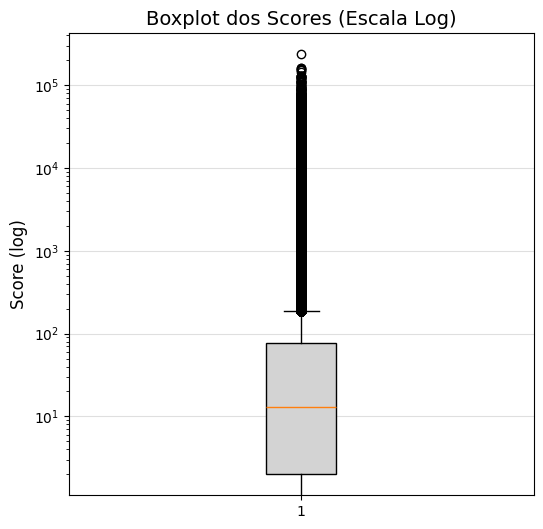

In [85]:
plt.figure(figsize=(6, 6))
plt.boxplot(df['score'].dropna(), patch_artist=True, boxprops=dict(facecolor='lightgray'))

plt.yscale('log') 

plt.title("Boxplot dos Scores (Escala Log)", fontsize=14)
plt.ylabel("Score (log)", fontsize=12)
plt.grid(axis='y', alpha=0.4)
plt.show()

Grande parte dos posts tem 10 de score, mas existe uma boa quantidade com até 100, ao passar disso, se configuram os outliers, que não são poucos também, portanto, pode se dizer que a comunidade é engajada

In [ ]:
import re

def parse_comments_v2(text):
    if not isinstance(text, str):
        return 0
    
    # Busca um padrão de dígitos (\d+) seguido de um espaço e a palavra 'comment'
    # O parênteses indica que só queremos o número (grupo 1)
    match = re.search(r'(\d+)\s*comment', text, re.IGNORECASE)
    
    if match:
        return int(match.group(1))
    return 0

# Aplicando a nova função
df['comments'] = df['comments_text'].apply(parse_comments_v2)

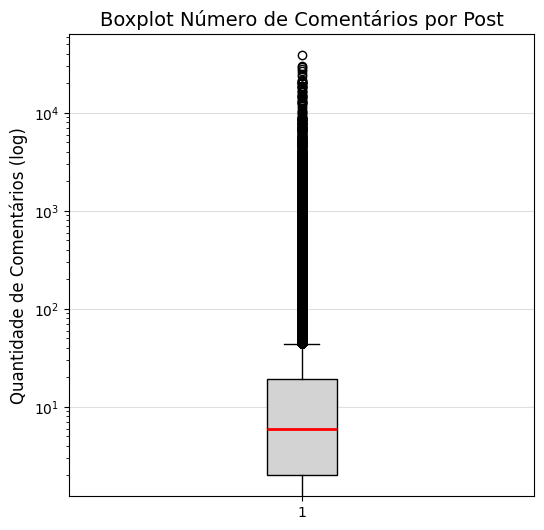

In [ ]:

plt.figure(figsize=(6, 6))

# Criando o boxplot
# Usamos .dropna() para garantir que valores nulos não quebrem o gráfico
plt.boxplot(df['comments'].dropna(), patch_artist=True, 
            boxprops=dict(facecolor='lightgray'),
            medianprops=dict(color='red', linewidth=2))

plt.yscale('log')

plt.title("Boxplot Número de Comentários por Post", fontsize=14)
plt.ylabel("Quantidade de Comentários (log)", fontsize=12)
plt.grid(axis='y', alpha=0.4)

plt.show()

É possível ver que os posts apresentam menos comentários em comparação aos scores, como o esperado, tendo em grande parte menos de 20 comentários, mas é possível que existem bastantes outliers que geraram um grande engajamento

---

### 4. Análise dos Títulos

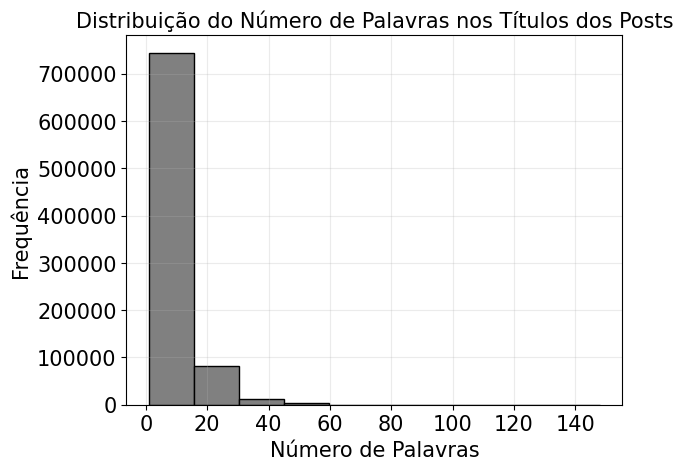

In [ ]:
plt.Figure(figsize=(10, 6))
x = df['title'].apply(lambda t: len(t.split()))
plt.hist(x, bins=10, edgecolor='black', facecolor='gray')
plt.title('Distribuição do Número de Palavras nos Títulos dos Posts', fontsize=15)
plt.xlabel('Número de Palavras', fontsize=15)
plt.ylabel('Frequência', fontsize=15)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.grid(alpha=0.25)
plt.show()

In [ ]:
import os
import json
import pandas as pd

rows = []
erros = []

# Itera por cada profundidade
for depth in range(3 + 1):
    dir_ = f"data3/{depth}/subreddits"
    if not os.path.exists(dir_):
        continue
    for filename in os.listdir(dir_):
        if filename.endswith(".json"):
            path = os.path.join(dir_, filename)
            try:
                with open(path, "r", encoding="utf-8") as f:
                    posts = json.load(f)
                # Adiciona a profundidade em cada post para rastreabilidade
                for post in posts:
                    post["depth"] = depth
                rows.extend(posts)
            except json.JSONDecodeError:
                erros.append(path)

print(f"Arquivos com erro: {len(erros)}")
print(f"Posts carregados: {len(rows)}")

df = pd.DataFrame(rows)
df.head()

In [ ]:
KEYWORDS_RELEVANTES = [
    # Red pill / manosphere
    "redpill", "red pill", "blackpill", "black pill", "bluepill", "blue pill",
    "mgtow", "incel", "hypergamy", "pickup", "pua", "mens rights",
    "trp", "manosphere", "looksmaxxing", "looksmax",

    # Gênero
    "women", "woman", "female", "male", "gender", "feminist", "feminism",
    "femininity", "masculinity", "tradwife", "trad wife",

    # Termos misóginos
    "femoid", "foid", "roastie", "stacy", "chad", "betabux",
    "alpha male", "beta male", "sigma male", "cock carousel",
    "sexual market value", "smv", "hypergamy",

    # Relacionamentos
    "dating", "relationship", "marriage", "divorce", "attraction",
    "tinder", "boyfriend", "girlfriend", "hookup",

    # Misoginia geral
    "inferior", "submissive", "obey", "belong",
]

def tem_keyword(title):
    if not isinstance(title, str):
        return False
    title_lower = title.lower()
    for kw in KEYWORDS_RELEVANTES:
        if kw in title_lower:
            return True
    return False

# 1. Aplica a função de keyword uma única vez no DataFrame original
df['relevante'] = df['title'].apply(tem_keyword)

# 2. Agrupa por depth e calcula as estatísticas de uma vez só
stats = df.groupby('depth')['relevante'].agg(['count', 'sum'])

# 3. Calcula as porcentagens
stats['% relevante'] = (stats['sum'] / stats['count']) * 100
stats['fora_do_tema'] = stats['count'] - stats['sum']
stats['% fora_do_tema'] = (stats['fora_do_tema'] / stats['count']) * 100

# 4. Exibe os resultados formatados
for d in stats.index:
    print(f"___________________________________________________")
    print(f"Total de posts (depth={d})      : {stats.loc[d, 'count']}")
    print(f"Posts relevantes (depth={d})    : {stats.loc[d, 'sum']} ({stats.loc[d, '% relevante']:.1f}%)")
    print(f"Posts fora do tema (depth={d})  : {stats.loc[d, 'fora_do_tema']} ({stats.loc[d, '% fora_do_tema']:.1f}%)")

___________________________________________________
Total de posts (depth=0)      : 1051
Posts relevantes (depth=0)    : 369 (35.1%)
Posts fora do tema (depth=0)  : 682 (64.9%)
___________________________________________________
Total de posts (depth=1)      : 34643
Posts relevantes (depth=1)    : 1896 (5.5%)
Posts fora do tema (depth=1)  : 32747 (94.5%)
___________________________________________________
Total de posts (depth=2)      : 808165
Posts relevantes (depth=2)    : 12481 (1.5%)
Posts fora do tema (depth=2)  : 795684 (98.5%)


---

## **Conclusão e limitações**

É possível ver que a quantidade de posts relevantes vai se perdendo ao longo da profundidade, ou seja, posts sobre outros assuntos vão sendo encontrados